# Introduction
Elections has an importance at any country. For this reason, we did an
exploratory data analysis of Brazilian election data from 2022, retrieved
from Superior Electoral Court (TSE, in Brazilian Portuguese). We performed
univariate and multivariate analysis to describe and investigate
relationships about vote, party and region, which includes a data
dictionary as well. We found the job, mayor or councilor, plays an
important role in the amount of votes received. Moreover, we also found
a positive correlation between the number of mayors an councilors elected
by party.

In Dataset Analysis section we removed duplicated lines, unimportant
columns and treated null values. Then, in Exploratory Data Analysis
section, univariate and multivariate analysis were performed, followed by
correlation analysis between mayors and councilors elected.

# Dataset Analysis
In this section we just examine data frame structure, by checking
its data type, duplicated rows and columns. After this
preliminary analysis, we provide a data dictionary.

## Importing Required Modules

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

In [2]:
# added project root to path in order to import local modules
sys.path.append(str(Path(os.path.abspath('')).resolve().parents[0]))

In [3]:
from brazilian_elections.config import PROCESSED_DATA_DIR
from brazilian_elections.config import RAW_DATA_DIR
from brazilian_elections.config import REPORTS_DIR
from brazilian_elections.config import FIGURES_DIR

2025-03-30 16:24:11.462 | INFO     | brazilian_elections.config:<module>:12 - PROJ_ROOT path is: /home/gasobral/Meus Arquivos/data-science/brazilian_elections


In [4]:
# checking if the project directory structure was loaded properly
print(f"RAW_DATA_DIR path:       {RAW_DATA_DIR}\n"
      f"PROCESSED_DATA_DIR path: {PROCESSED_DATA_DIR}\n")

print(f"REPORTS_DIR path:        {REPORTS_DIR}\n"
      f"FIGURES_DIR path:        {FIGURES_DIR}\n")

RAW_DATA_DIR path:       /home/gasobral/Meus Arquivos/data-science/brazilian_elections/data/raw
PROCESSED_DATA_DIR path: /home/gasobral/Meus Arquivos/data-science/brazilian_elections/data/processed

REPORTS_DIR path:        /home/gasobral/Meus Arquivos/data-science/brazilian_elections/reports
FIGURES_DIR path:        /home/gasobral/Meus Arquivos/data-science/brazilian_elections/reports/figures



## Loading the Data Set

In [5]:
from brazilian_elections import dataset

In [6]:
dataset.main()

2025-03-30 16:24:11.536 | INFO     | brazilian_elections.dataset:main:25 - Processing dataset...


0it [00:00, ?it/s]

2025-03-30 16:24:11.540 | INFO     | brazilian_elections.dataset:main:31 - Processing the file /home/gasobral/Meus Arquivos/data-science/brazilian_elections/data/raw/.gitkeep.
2025-03-30 16:24:11.541 | WARNING  | brazilian_elections.dataset:main:34 - Ignoring hiddne file .gitkeep
2025-03-30 16:24:11.542 | INFO     | brazilian_elections.dataset:main:31 - Processing the file /home/gasobral/Meus Arquivos/data-science/brazilian_elections/data/raw/clean_data.zip.
2025-03-30 16:24:11.544 | INFO     | brazilian_elections.dataset:main:38 - File clean_data.zip is compressed.
2025-03-30 16:24:11.545 | INFO     | brazilian_elections.dataset:main:41 - Decompressing the file clean_data.zip


2it [00:00,  6.24it/s]

2025-03-30 16:24:11.857 | INFO     | brazilian_elections.dataset:main:44 - Extracted file clean_data.zip into directory /home/gasobral/Meus Arquivos/data-science/brazilian_elections/data/processed
2025-03-30 16:24:11.860 | SUCCESS  | brazilian_elections.dataset:main:51 - Processing dataset complete.


In [7]:
data_frame = pd.read_csv( PROCESSED_DATA_DIR / 'clean_data.csv', engine='pyarrow')

## Checking Data Set Structure

In [8]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518675 entries, 0 to 518674
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0                               518675 non-null  int64  
 1   uf                          518675 non-null  object 
 2   type_id                     518675 non-null  int64  
 3   codigo_tse                  518675 non-null  int64  
 4   nome_municipio              518675 non-null  object 
 5   capital                     518675 non-null  int64  
 6   codigo_ibge                 518675 non-null  int64  
 7   job_count                   518675 non-null  int64  
 8   elector_count               518675 non-null  object 
 9   elector_presence            518675 non-null  int64  
 10  absentees                   518675 non-null  int64  
 11  nominal_votes               518675 non-null  int64  
 12  blank_votes                 518675 non-null  int64  
 13  total_null_vot

In [9]:
data_frame.head()

,,uf,type_id,codigo_tse,nome_municipio,capital,codigo_ibge,job_count,elector_count,elector_presence,...,vote_count,candidate_number,candidate_name,candidate_coligation,candidate_vice_name,candidate_vote_destination,candidate_vote_count,legend_votes,job,main_party
0,0,AC,11,1120,ACRELÂNDIA,0,1200013,1,n,7093,...,7093,11,CAETANO,PP - PP / SOLIDARIEDADE / PSD,MARQUINHOS,Válido,2405,NaN,prefeito,PP
1,1,AC,11,1120,ACRELÂNDIA,0,1200013,1,n,7093,...,7093,12,HADAMÉS WILSON,PDT,LUCAS NOBRE,Válido,1237,NaN,prefeito,PDT
2,2,AC,11,1120,ACRELÂNDIA,0,1200013,1,s,7093,...,7093,15,OLAVINHO,MDB - PL / MDB / PSDB,GRAIA,Válido,2638,NaN,prefeito,MDB
3,3,AC,11,1120,ACRELÂNDIA,0,1200013,1,n,7093,...,7093,90,ROSA DO EURICO,PROS - PSL / PROS,LUIZ DO GÁS,Válido,569,NaN,prefeito,PROS
4,4,AC,13,1120,ACRELÂNDIA,0,1200013,9,n,7093,...,7093,11130,PAULA CLEURIDES,PP,,Válido,1,415.0,vereador,PP


In [10]:
data_frame.duplicated().sum()

0

By first looking at the data, we can see that only the column
*legend_votes* has some missing values. This happens because some jobs,
like mayor, do not receive legend votes, which are votes given for
the main party instead of candidate. When analysing data for mayors, we
can simply ignore this column. We also checked that there are no
duplicated rows.

We can also note that the frist column just
enumerate the rows of the dataset. Since we already have an index for
enumerating the rows, then it is ok to remove this column.

Moreover, as the columns *type_id*, *codigo_tse*, *codigo_ibge* and
*job_count* refer to some internal codes used by brazilian government
agencies, then we will remove these columns as well.

In [11]:
data_frame.drop(columns=['', 'type_id', 'codigo_tse', 'codigo_ibge', 'job_count'],
                inplace=True)

In [12]:
data_frame.columns

Index(['uf', 'nome_municipio', 'capital', 'elector_count', 'elector_presence',
       'absentees', 'nominal_votes', 'blank_votes', 'total_null_votes',
       'null_votes', 'technical_null_votes', 'valid_votes', 'nulled_votes',
       'judically_nulled_votes', 'vote_count', 'candidate_number',
       'candidate_name', 'candidate_coligation', 'candidate_vice_name',
       'candidate_vote_destination', 'candidate_vote_count', 'legend_votes',
       'job', 'main_party'],
      dtype='object')

In [13]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518675 entries, 0 to 518674
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   uf                          518675 non-null  object 
 1   nome_municipio              518675 non-null  object 
 2   capital                     518675 non-null  int64  
 3   elector_count               518675 non-null  object 
 4   elector_presence            518675 non-null  int64  
 5   absentees                   518675 non-null  int64  
 6   nominal_votes               518675 non-null  int64  
 7   blank_votes                 518675 non-null  int64  
 8   total_null_votes            518675 non-null  int64  
 9   null_votes                  518675 non-null  int64  
 10  technical_null_votes        518675 non-null  int64  
 11  valid_votes                 518675 non-null  int64  
 12  nulled_votes                518675 non-null  int64  
 13  judically_null

After removing the columns, the memory usage for the data frame was
slightly reduced, going from 114.8 Mb to 95Mb.

## Data Dictionary
Before data is analyzed, we provide a data dictionary break down by variable type.

- *Categorical Data*
  - **uf**: acronym of brazilian state;
  - **nome_municipio**: name of the city;
  - **capital**: it is a binary variable which indicates if the ctiy is capital (capital=1) or not (capital=0);
  - **elector_presence**: the presence of ellectors;
  - **candidate_name**: name of the candidate;
  - **candidate_coligation**: coalition (parties) at which a candidadate belogns to;
  - **candidate_vice_name**: name of the vice candidate;
  - **candidate_vote_destination**: this column tells if the vote is valid, nulled by justice, null or voted a party (instead of canidate);
  - **job**: the job a candidate applied for, mayor or councilor;
  - **main_party**: the party that a candidate belongs to;
- *Numerical Data*
  - **elector_presence**: number of voters of a polling station;
  - **absentees**: number of voters that did not vote;
  - **nominal_votes**: number of votes given for a candidate;
  - **blank_votes**: number of blank votes;
  - **total_null_votes**: total number of nulled votes (amount all types of nulled votes);
  - **null_votes**: number of null votes (vote made by a voter);
  - **technical_null_votes**: number of votes which got nulled due to some issue (disqualified candidate, cancelled polling station and so on);
  - **valid_votes**: number of valid notes (used to elect a candidate);
  - **nulled_votes**: number of votes which got nulled;
  - **judically_nulled_votes**: number of votes which got nulled by justice;
  - **vote_count**: total number of votes, that is, vote_count = blank_votes + total_null_votes + valid_votes;
  - **candidate_number**: unique number that identifies the candidate;
  - **candidate_vote_count**: total number of votes given for a candidate;
  - **legend_votes**: votes given to a party.

# Exploratory Data Analysis

## Univariate Analysis
We start our analysis by checking the numerical data by providing
basic statistics about its central tendency and dispersion.

In [14]:
data_frame.describe().T

,count,mean,std,min,25%,50%,75%,max
capital,518675.0,0.045682,0.208794,0.0,0.0,0.0,0.0,1.0
elector_presence,518675.0,108240.051886,463464.406175,0.0,7457.0,17723.0,54920.0,6354100.0
absentees,518675.0,39096.946890,194290.900277,0.0,1626.0,4686.0,17110.0,2632587.0
nominal_votes,518675.0,85816.629679,332232.094103,0.0,6658.0,15797.0,48107.0,5338156.0
blank_votes,518675.0,6527.062305,39294.551284,0.0,94.0,327.0,1936.0,577648.0
total_null_votes,518675.0,7988.322362,47600.924033,0.0,221.0,562.0,2227.0,660927.0
null_votes,518675.0,7905.278803,47344.473815,0.0,218.0,551.0,2149.0,660401.0
technical_null_votes,518675.0,83.043559,489.047478,0.0,0.0,0.0,9.0,7649.0
valid_votes,518675.0,92613.526806,372970.020087,0.0,7032.0,16548.0,50626.0,5338156.0
nulled_votes,518675.0,0.516559,10.266837,0.0,0.0,0.0,0.0,272.0


In [15]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

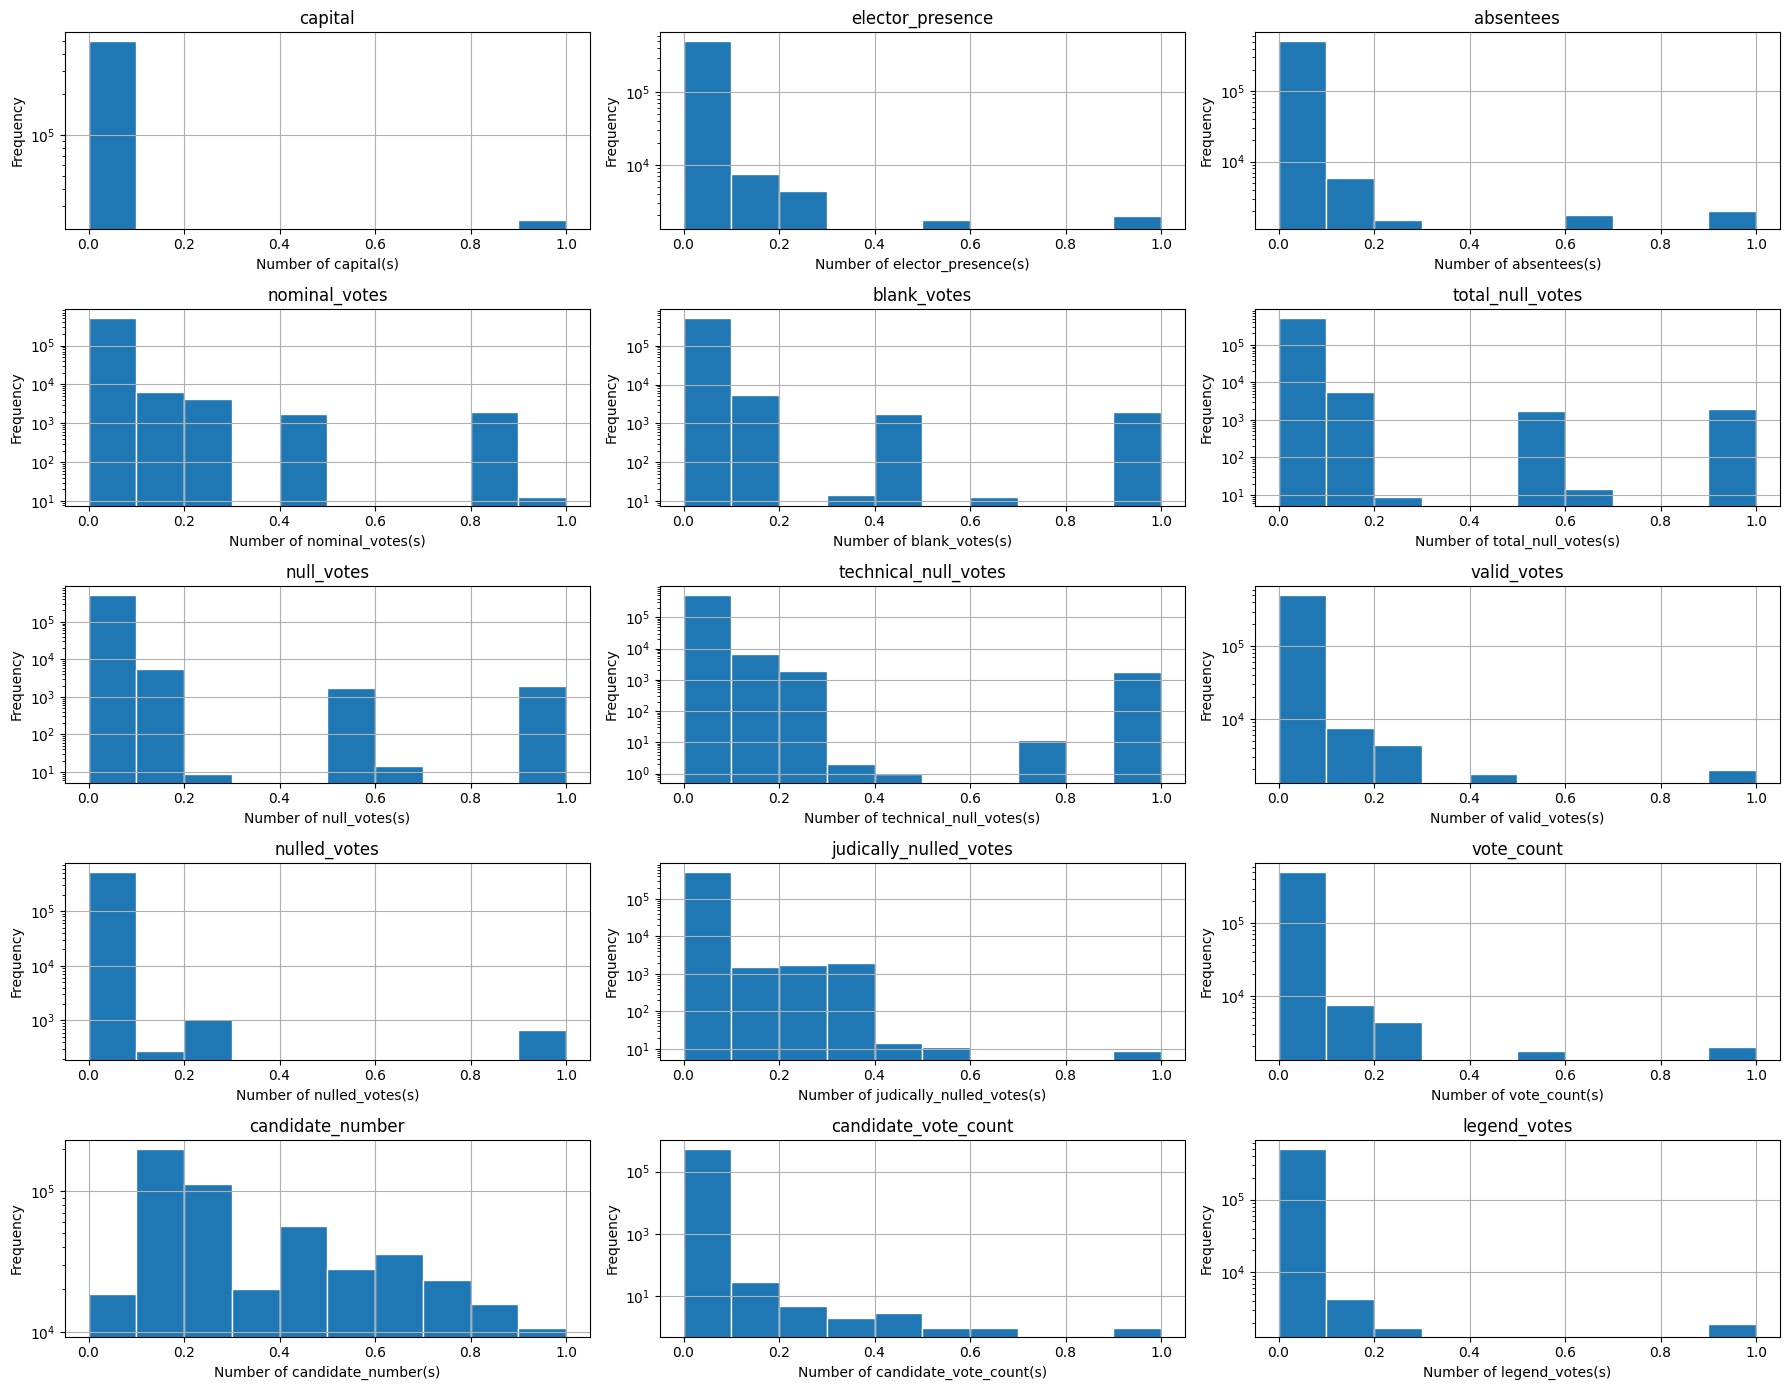

In [16]:
## generate the histograms for each numerical column in the data frame
numeric_cols = data_frame.select_dtypes(include='number').columns

## normalize the data in order to have the histograms comparable
min_max_scaler = MinMaxScaler()
normalized_data = min_max_scaler.fit_transform(data_frame[numeric_cols])
normalized_df = pd.DataFrame(normalized_data,
                             columns=numeric_cols)

## creates a figure with 3 histograms for each row
num_numeric_cols = len(numeric_cols)
fig, axs = plt.subplots(num_numeric_cols // 3,
                        3,
                        figsize=(18,14))

## the axes was flatten to make easier to iterate over it
axs = axs.flatten()

## draw the histograms
for i, column in enumerate(normalized_df):
    normalized_df[column].hist(ax=axs[i],
                               edgecolor='white',
                               log=True)
    axs[i].set_title(column)
    axs[i].set_xlabel(f'Number of {column}(s)')
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The histograms of variables related to the vote are asymmetric to the
right and their pattern are a bit similar. Note that there is a high
concentration of data at the firsts bins, which could be happening for
a few reasons. First, we are counting the votes for mayors with
councilors. Since the amount of former job is greater than mayors
and usually councilors are elected with less amount of votes, then
this could explain the data concentration at the firsts bins. Moreover,
these histograms also put together data from cities with different
amount of population, which also affects the number of votes. And also,
this could be the reason of some gaps (which suggests existence of
    outliers) in some histograms. Due to these observations, in our
multivariate analysis, we will consider breaking down voting data by
job, state and party to have a better understating of these data.

In [17]:
## showing the skewness for each numeric variable, in order to
## check how data is assymatric (or not)
normalized_df.skew()

capital                     4.351843
elector_presence           10.635787
absentees                  10.921184
nominal_votes               9.867134
blank_votes                12.444593
total_null_votes           11.547830
null_votes                 11.615983
technical_null_votes       12.903658
valid_votes                10.281834
nulled_votes               24.692155
judically_nulled_votes      9.770381
vote_count                 10.635787
candidate_number            1.043210
candidate_vote_count      167.091353
legend_votes               13.412882
dtype: float64

Capital distribution is expected to have few frequencies of 1, since
the minority of cities are capitals.

It is important to recall that, mayor and councilor number have a
prefix which identifies their main party. Since the prefix and party
number are the same, then we will only analyze main party data
(categorical variable).

Below we plot the box plot for each numeric variable. They confirmed the
existence of outliers. As mentioned before, this can happen because a
councilor requires less votes to be elected than a mayor. And also, we
will how candidate vote is distributed among the jobs, because it could
happen that a few candidates concentrate the majority of votes. In
addition, we will check the relation between votes, job and state, since
population number may affect the number of votes.

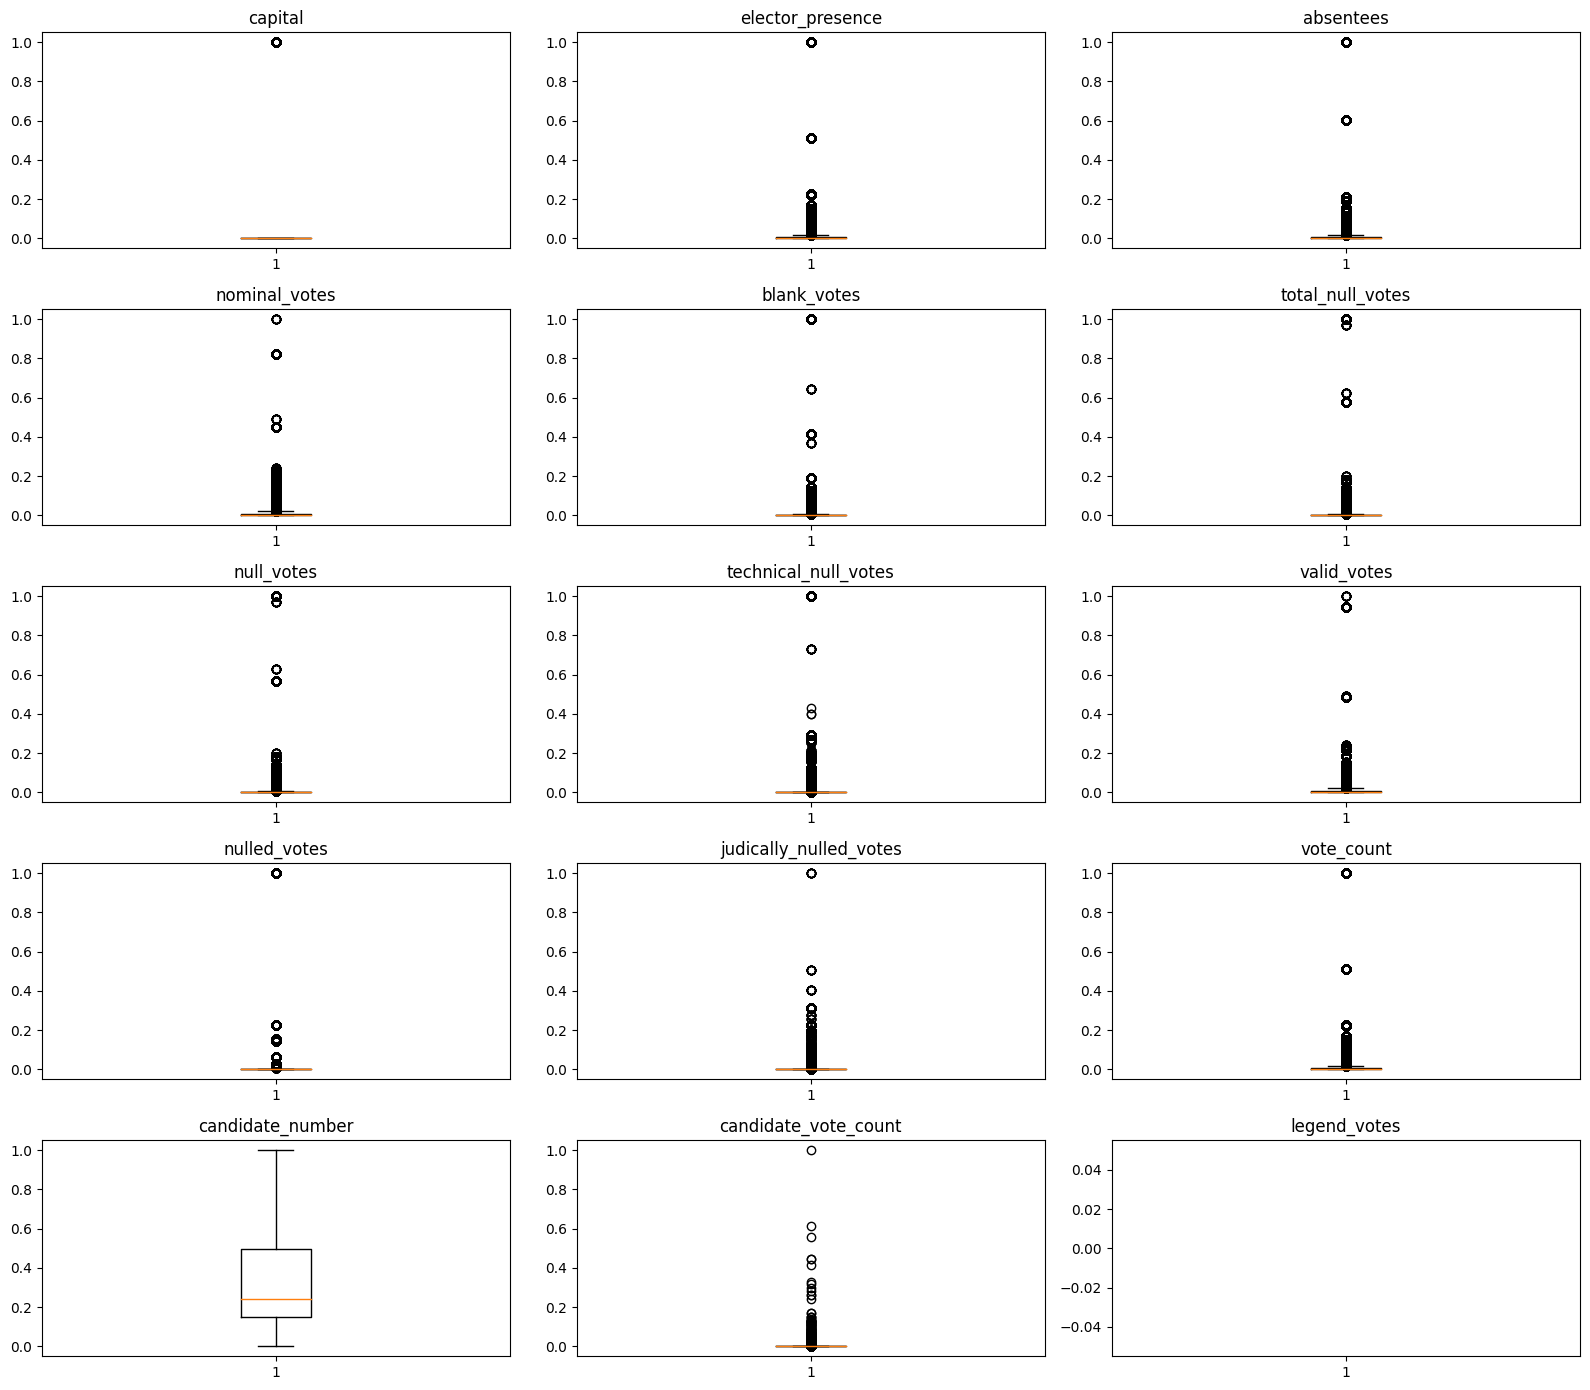

In [18]:
## creates a figure with 3 histograms for each row
fig, axs = plt.subplots(num_numeric_cols // 3,
                        3,
                        figsize=(16,14))

## the axes was flatten to make easier to iterate over it
axs = axs.flatten()

## draw the boxplots
for i,column in enumerate(numeric_cols):
    axs[i].boxplot(normalized_df[column])
    axs[i].set_title(column)

plt.tight_layout()
plt.show()

In [19]:
## obtaining the categorical variables of the data frame
category_cols = data_frame.select_dtypes(include='object').columns

## priting the amount of unique categories for each
## categoriacal variable
for i, column in enumerate(category_cols):
    print(f'Data for the column: {column}\n'
          f'{data_frame[column].value_counts()}\n\n')

Data for the column: uf
uf
SP    88074
MG    76549
BA    38700
PR    34578
RS    31455
RJ    24742
GO    23019
PA    21991
SC    20254
PE    19535
MA    19238
CE    14936
MT    11932
ES    11638
PB    11386
AM     9793
PI     9726
RN     9654
MS     8016
TO     7930
AL     6889
SE     6393
RO     5473
AC     2767
AP     2263
RR     1744
Name: count, dtype: int64


Data for the column: nome_municipio
nome_municipio
SÃO PAULO               1975
RIO DE JANEIRO          1749
SALVADOR                1527
BELO HORIZONTE          1506
MANAUS                  1379
                        ... 
FRUTUOSO GOMES            14
INHACORÁ                  13
BARRA DO RIO AZUL         13
MATO QUEIMADO             13
CURRAL NOVO DO PIAUÍ      11
Name: count, Length: 5294, dtype: int64


Data for the column: elector_count
elector_count
n    455290
s     63385
Name: count, dtype: int64


Data for the column: candidate_name
candidate_name
ANA PAULA           244
PAULINHO            236
ROSE                1

For the variable nome_municipio, we can note that highest frequencies are
associated with the cities with high population. Which is a expected
result since the number of candidates tends to be higher in big cities, as
the number of councilors depends on the number of citizens. The same
happens to uf, which identifies a Brazilian state.

We will not analyze further candidate_name and candidate_vice_name
since they are redundant information, because a candidate is uniquely
identified by a number. Moreover, it is more convenient to work with
numbers. In particular, for candidate_vice_name, you can see that
exists 500035 blank names (null). This happens because councilors
do not have a vice.

Regarding the job, as expected, the majority of candidates are
councilors, whereas the minority are mayors. And most of votes are
valid, just a few of them are null.

The candidate_coligation shows a candidate electoral alliance, however,
for voting purposes, what matter is the candidate main party. So we
will focus our analysis on this column. By executing the method
*value counts* of this column, we can see that the first 5 parties are
have center or right political alignment. Below we plot bar plots for
some variable in order to better visualize their data.

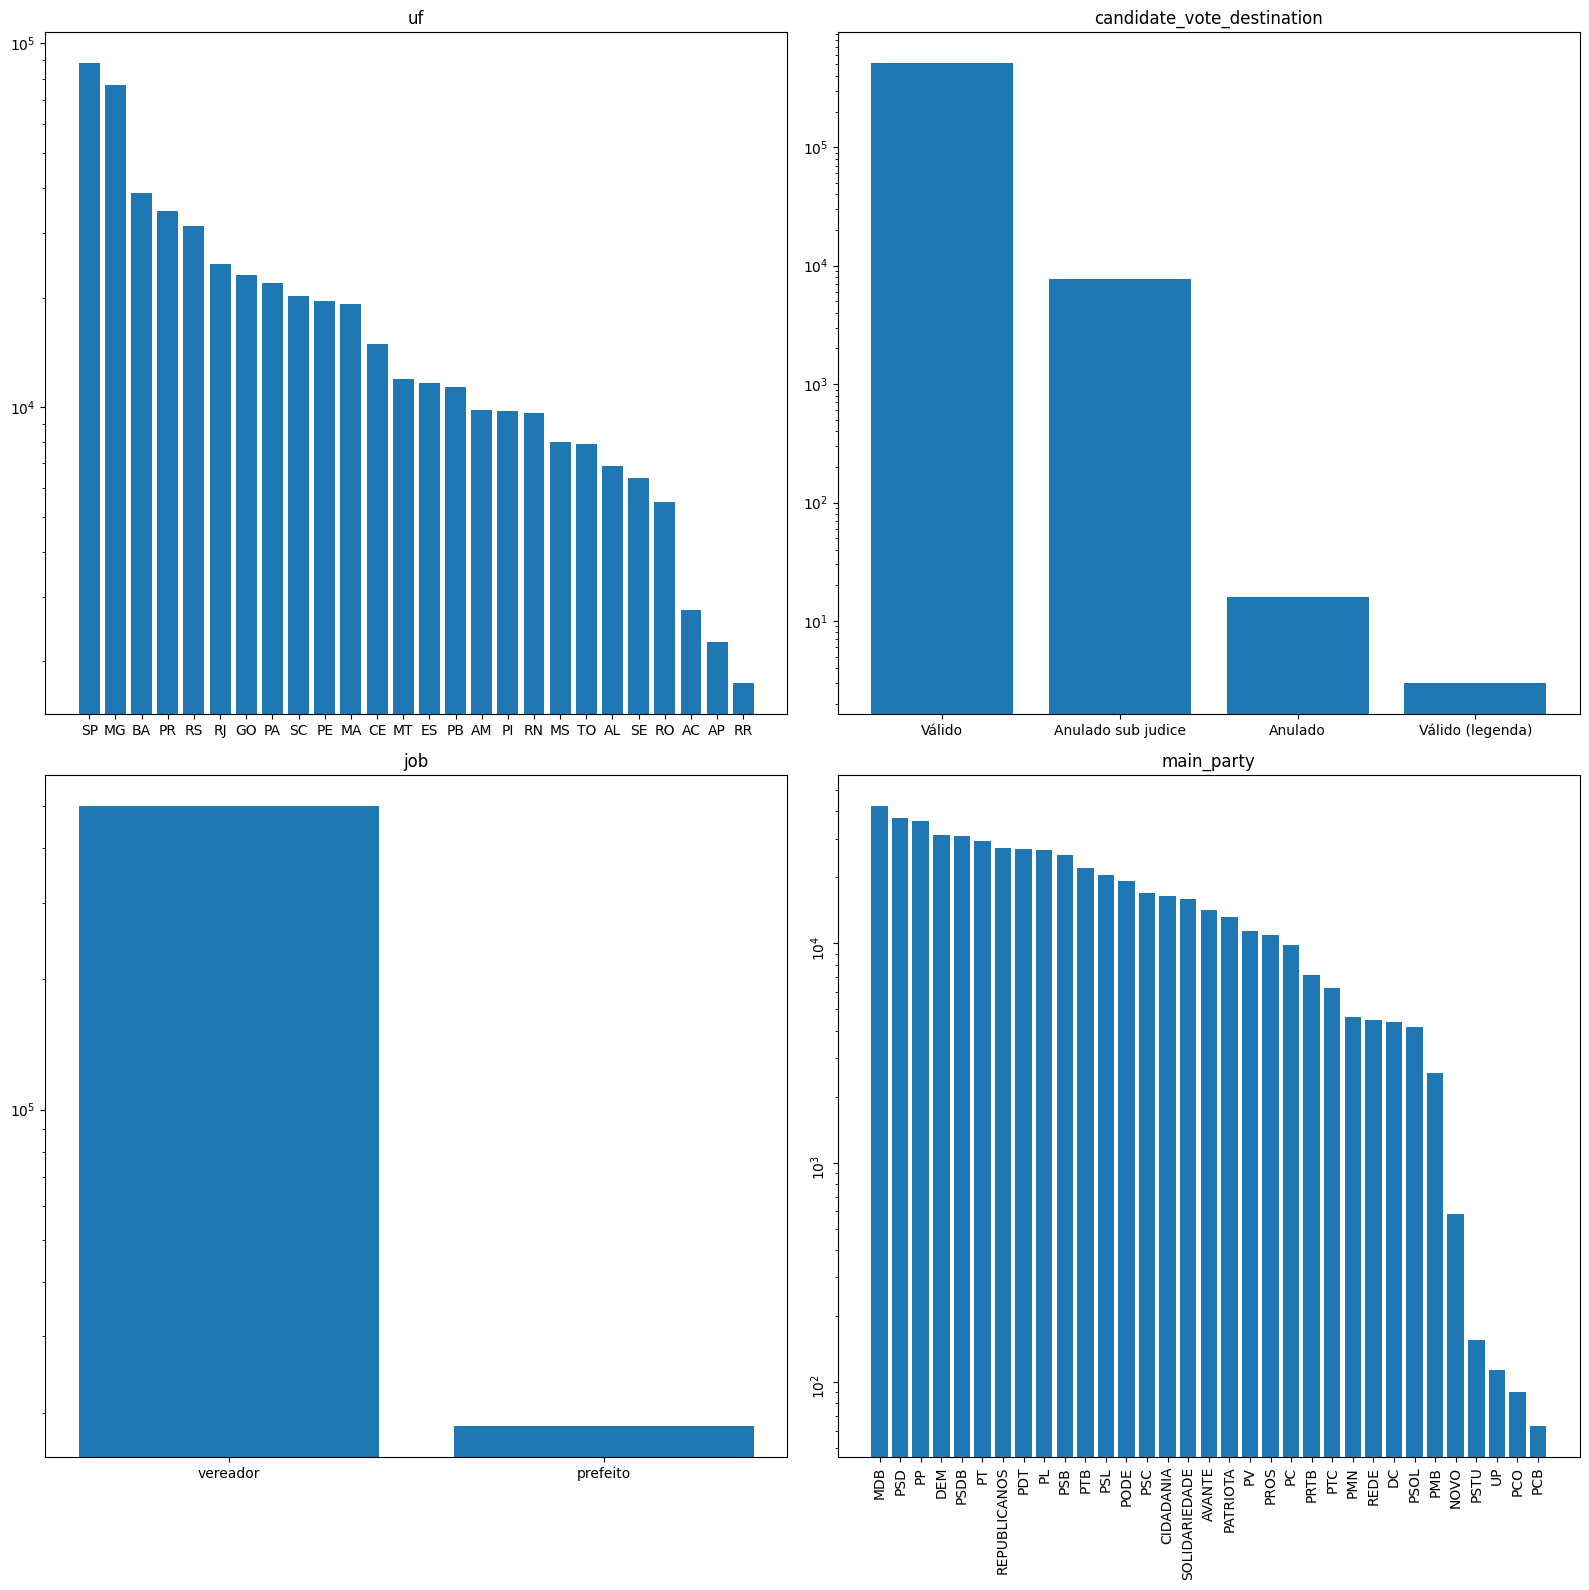

In [20]:
## creating bar plots for some categorical variables
columns = ['uf', 'candidate_vote_destination', 'job', 'main_party']

fig, axs = plt.subplots(2,
                        2,
                        figsize=(16,16))

axs = axs.flatten()

for i,column in enumerate(columns):
    counts = data_frame[column].value_counts()
    axs[i].bar(counts.index,
               counts.values,
               log=True)
    axs[i].set_title(column)

    ## rotating the labels for the main_party column
    ## since there are too many labels
    if column == 'main_party' :
        axs[i].tick_params(labelrotation=90)

plt.tight_layout()
plt.show()

### Multivariate Analysis
We start our multivariate analysis by checking the linear
correlation between numerical variables.

,capital,elector_presence,absentees,nominal_votes,blank_votes,total_null_votes,null_votes,technical_null_votes,valid_votes,nulled_votes,judically_nulled_votes,vote_count,candidate_number,candidate_vote_count,legend_votes
capital,1.000000,0.604618,0.568918,0.637739,0.517444,0.519506,0.517337,0.482411,0.623476,0.213499,0.460537,0.604618,0.045821,0.055818,0.488749
elector_presence,0.604618,1.000000,0.992067,0.997887,0.985864,0.986902,0.986955,0.512321,0.999345,0.028906,0.883675,1.000000,0.039703,0.077567,0.972500
absentees,0.568918,0.992067,1.000000,0.986066,0.987131,0.995463,0.995202,0.547340,0.988218,0.026837,0.886501,0.992067,0.035397,0.075562,0.967203
nominal_votes,0.637739,0.997887,0.986066,1.000000,0.973505,0.976982,0.976755,0.534261,0.999400,0.034386,0.876221,0.997887,0.042640,0.086073,0.957785
blank_votes,0.517444,0.985864,0.987131,0.973505,1.000000,0.989574,0.990447,0.434359,0.980136,0.012823,0.871434,0.985864,0.031246,0.060403,0.992575
total_null_votes,0.519506,0.986902,0.995463,0.976982,0.989574,1.000000,0.999962,0.528112,0.980887,0.015324,0.891526,0.986902,0.031258,0.075533,0.973956
null_votes,0.517337,0.986955,0.995202,0.976755,0.990447,0.999962,1.000000,0.520643,0.980876,0.015288,0.890917,0.986955,0.031055,0.075732,0.975675
technical_null_votes,0.482411,0.512321,0.547340,0.534261,0.434359,0.528112,0.520643,1.000000,0.515441,0.011532,0.526425,0.512321,0.036107,0.020324,0.346943
valid_votes,0.623476,0.999345,0.988218,0.999400,0.980136,0.980887,0.980876,0.515441,1.000000,0.032013,0.877252,0.999345,0.041605,0.079738,0.966728
nulled_votes,0.213499,0.028906,0.026837,0.034386,0.012823,0.015324,0.015288,0.011532,0.032013,1.000000,0.037562,0.028906,0.008499,0.000207,0.011839


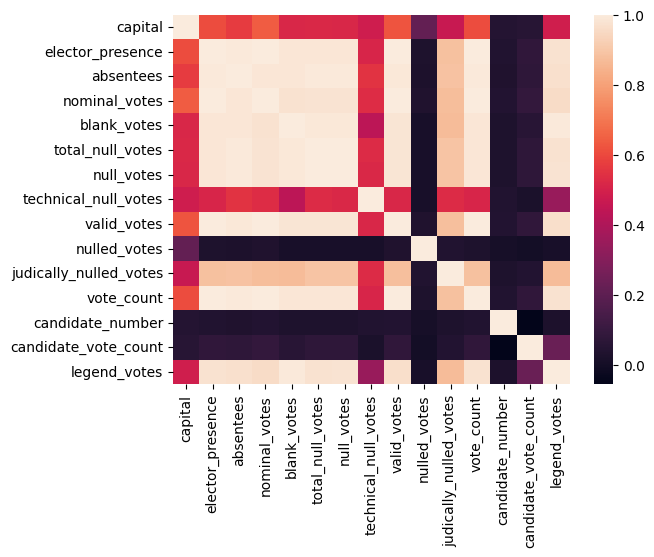

In [21]:
import seaborn as sns

## correlação entre as variáveis numéricas
correlation_matrix = data_frame[numeric_cols].corr()
sns.heatmap(correlation_matrix)
correlation_matrix

From the correlation matrix, we have the following notes:

- the variables *elector_presence*, *absentees*, *nominal_votes*,
  *blank_votes*, *total_null_votes*, *null_votes*, *valid_votes*,
  *judically_nulled_votes*, *vote_count* and *legend_votes* are strongly
  linear correlated to each other. For example, if the
  number of elector presence increases, then the absentees the votes
  (nominal, null, total and count) increases as well; which is expected;

- nulled_votes, candidate_number and candidate_vote_count do not have a
  strong linear correlation to any other variable;

- technical_null_votes and capital have a quite, but not strong, linear
  correlation to the other variables.

Now we are going to check how the vote is related to state and the job.

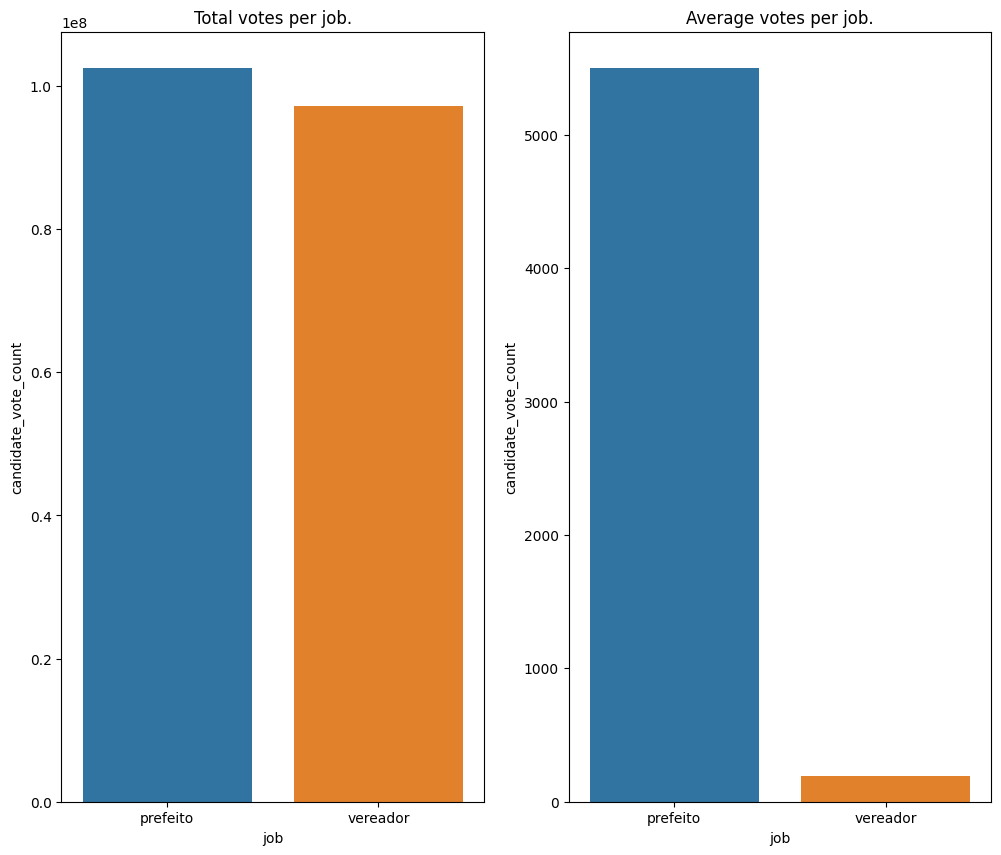

In [22]:
## creates the figure and axes objects for plotting
fig, eixo = plt.subplots(1,2, figsize=(12,10))

## compute the sum of candidate votes grouped per job
total_votes_per_job = data_frame.groupby(by='job')['candidate_vote_count'].sum()
total_votes_per_job = total_votes_per_job.reset_index(['job'])

g = sns.barplot(data=total_votes_per_job,
                x='job',
                y='candidate_vote_count',
                ax=eixo[0]
)

g.set_title('Total votes per job.')

## computes the average of candidate votes grouped per job
total_votes_per_job = data_frame.groupby(by='job')['candidate_vote_count'].mean()
total_votes_per_job = total_votes_per_job.reset_index(['job'])

h = sns.barplot(
    data=total_votes_per_job,
    x='job',
    y='candidate_vote_count',
    ax=eixo[1]
)

h.set_title('Average votes per job.')

plt.savefig(FIGURES_DIR / 'total_votes_per_job.png')

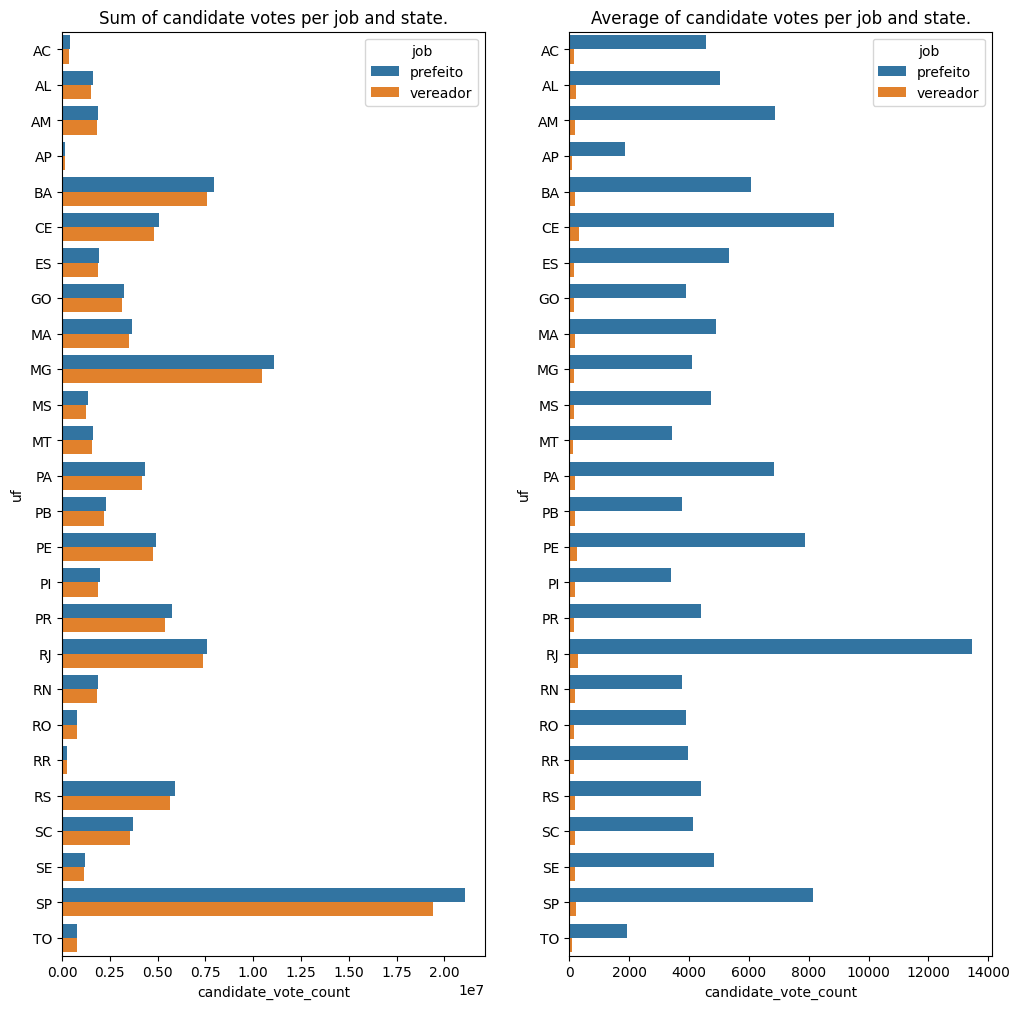

In [23]:
## code to plot bar graphs with total (resp. average) the candidate
## votes per job and state
fig, eixo = plt.subplots(1,2, figsize=(12,12))

vote_per_job = data_frame.groupby(by=['job', 'uf'])['candidate_vote_count'].sum()
vote_per_job = vote_per_job.reset_index(['job', 'uf'])

g = sns.barplot(
    data=vote_per_job,
    x='candidate_vote_count',
    y='uf',
    hue='job',
    ax=eixo[0]
)

g.set_title('Sum of candidate votes per job and state.')

vote_per_job = data_frame.groupby(by=['job', 'uf'])['candidate_vote_count'].mean()
vote_per_job = vote_per_job.reset_index(['job', 'uf'])

h = sns.barplot(
    data=vote_per_job,
    x='candidate_vote_count',
    y='uf',
    hue='job',
    ax=eixo[1]
)

h.set_title('Average of candidate votes per job and state.')

plt.savefig(FIGURES_DIR / 'candidate_votes_job_state.png')

Basic statistics for councilors for state AC.
count    2678.000000
mean      145.233383
std       273.886529
min         0.000000
10%         7.000000
25%        20.000000
50%        59.000000
75%       159.000000
90%       346.000000
max      3576.000000
Name: candidate_vote_count, dtype: float64

Basic statistics for councilors for state AL.
count     6571.000000
mean       233.263582
std        504.509897
min          0.000000
10%          6.000000
25%         21.000000
50%         84.000000
75%        273.000000
90%        578.000000
max      12038.000000
Name: candidate_vote_count, dtype: float64

Basic statistics for councilors for state AM.
count     9518.000000
mean       191.295335
std        523.017372
min          0.000000
10%          4.000000
25%         16.000000
50%         54.000000
75%        173.000000
90%        413.000000
max      13880.000000
Name: candidate_vote_count, dtype: float64

Basic statistics for councilors for state AP.
count    2173.000000
mean       75

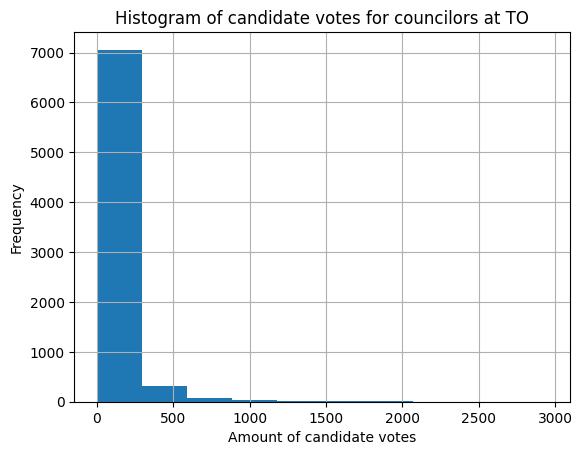

In [24]:
## checking how voting data is distributed for councilors per state
states = data_frame['uf'].unique()

for state in states:
    print(f'Basic statistics for councilors for state {state}.')
    councilors = data_frame[
    (data_frame['uf'] == state) & (data_frame['job'] == 'vereador')
    ]
    print(councilors['candidate_vote_count'].describe(percentiles=[.1, .25, .5, .75, .9]).T,
          end='\n\n')

## ploting a histogram of candidate votes for TO state
## to visualize its distribution
## TO state was picked because it generates a better visualization of
## the data distribution and it also has a distribution similar to all
## other states
fig, ax = plt.subplots()

councilors = data_frame[
(data_frame['uf'] == 'TO') & (data_frame['job'] == 'vereador')
]

councilors['candidate_vote_count'].hist(ax=ax)
ax.set_title(f'Histogram of candidate votes for councilors at TO')
ax.set_xlabel('Amount of candidate votes')
ax.set_ylabel('Frequency')
plt.show()

Basic statistics for mayors for state AC.
count       89.000000
mean      4563.539326
std      10609.160775
min          4.000000
10%        248.000000
25%        735.000000
50%       2294.000000
75%       3993.000000
90%       8637.800000
max      87987.000000
Name: candidate_vote_count, dtype: float64

Basic statistics for mayors for state AL.
count       318.000000
mean       5035.160377
std       11120.118398
min           9.000000
10%         125.000000
25%         919.750000
50%        2966.000000
75%        5389.250000
90%        9378.700000
max      110234.000000
Name: candidate_vote_count, dtype: float64

Basic statistics for mayors for state AM.
count       275.000000
mean       6859.130909
std       23553.030863
min           1.000000
10%         108.200000
25%         417.000000
50%        2292.000000
75%        5082.000000
90%        9915.400000
max      234088.000000
Name: candidate_vote_count, dtype: float64

Basic statistics for mayors for state AP.
count       90.00000

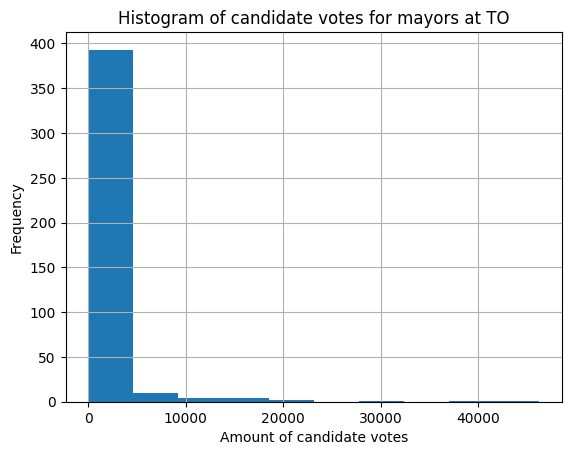

In [25]:
## checking show voting data is distributed for mayors per state
states = data_frame['uf'].unique()

for state in states:
    print(f'Basic statistics for mayors for state {state}.')
    mayors = data_frame[
    (data_frame['uf'] == state) & (data_frame['job'] == 'prefeito')
    ]
    print(mayors['candidate_vote_count'].describe(percentiles=[.1, .25, .5, .75, .9]).T,
          end='\n\n')

fig, ax = plt.subplots()
mayors['candidate_vote_count'].hist(ax=ax)
ax.set_title(f'Histogram of candidate votes for mayors at {state}')
ax.set_xlabel('Amount of candidate votes')
ax.set_ylabel('Frequency')
plt.show()

From the graphs above, we can note perceptible differences between jobs
when average candidate vote is analyzed, whereas total votes do not show a
noticeable difference. When we breakdown these votes per state, the
average votes between mayors and councilors show a great
difference. Average votes for councilors do not show a great variance and
they are quite similar, while average mayor votes have a greater variance.

Recall that we have 500035 councilors and 18640 mayors and, respectively,
they had 97261711 and 102463947 votes in total. Since the number of
councilors is greater than the number of mayors, then in average
councilors received less amount of votes than mayors. This allows us
to understand why we had a high votes frequency are at the first bins
in the histograms for numerical univariate analysis.

Moreover, we expected the high populated states had a great impact on the
number of votes received by a candidate. It does when we take in
consideration only the total votes. However, councilors average candidate
votes are quite similar among states (uf), and the mayor average votes for
Pernambuco (PE) and São Paulo (SP) are close, however Pernambuco has
7,018,098 voters and São Paulo 34,667,793 voters. When analyzing candidate
vote histogram for both jobs, we can note that only a few candidates
received a high amount of votes and most of them received a small amount
of votes. And also, 75% of data is within distance 0 from the
mean. Therefore, the job has a greater influence in candidate vote than
the state.

We also created a [dashboard](https://public.tableau.com/app/profile/gabriel.sobral/viz/election_analysis_17428265010000/Votebashboard)
with candidate vote per state and candidate vote per party, which can
be filtered by state, to provide a better data visualization for these
variables. In docs directory, you can find the *Tableau* and *Power BI*
files used to generate this dashboard.

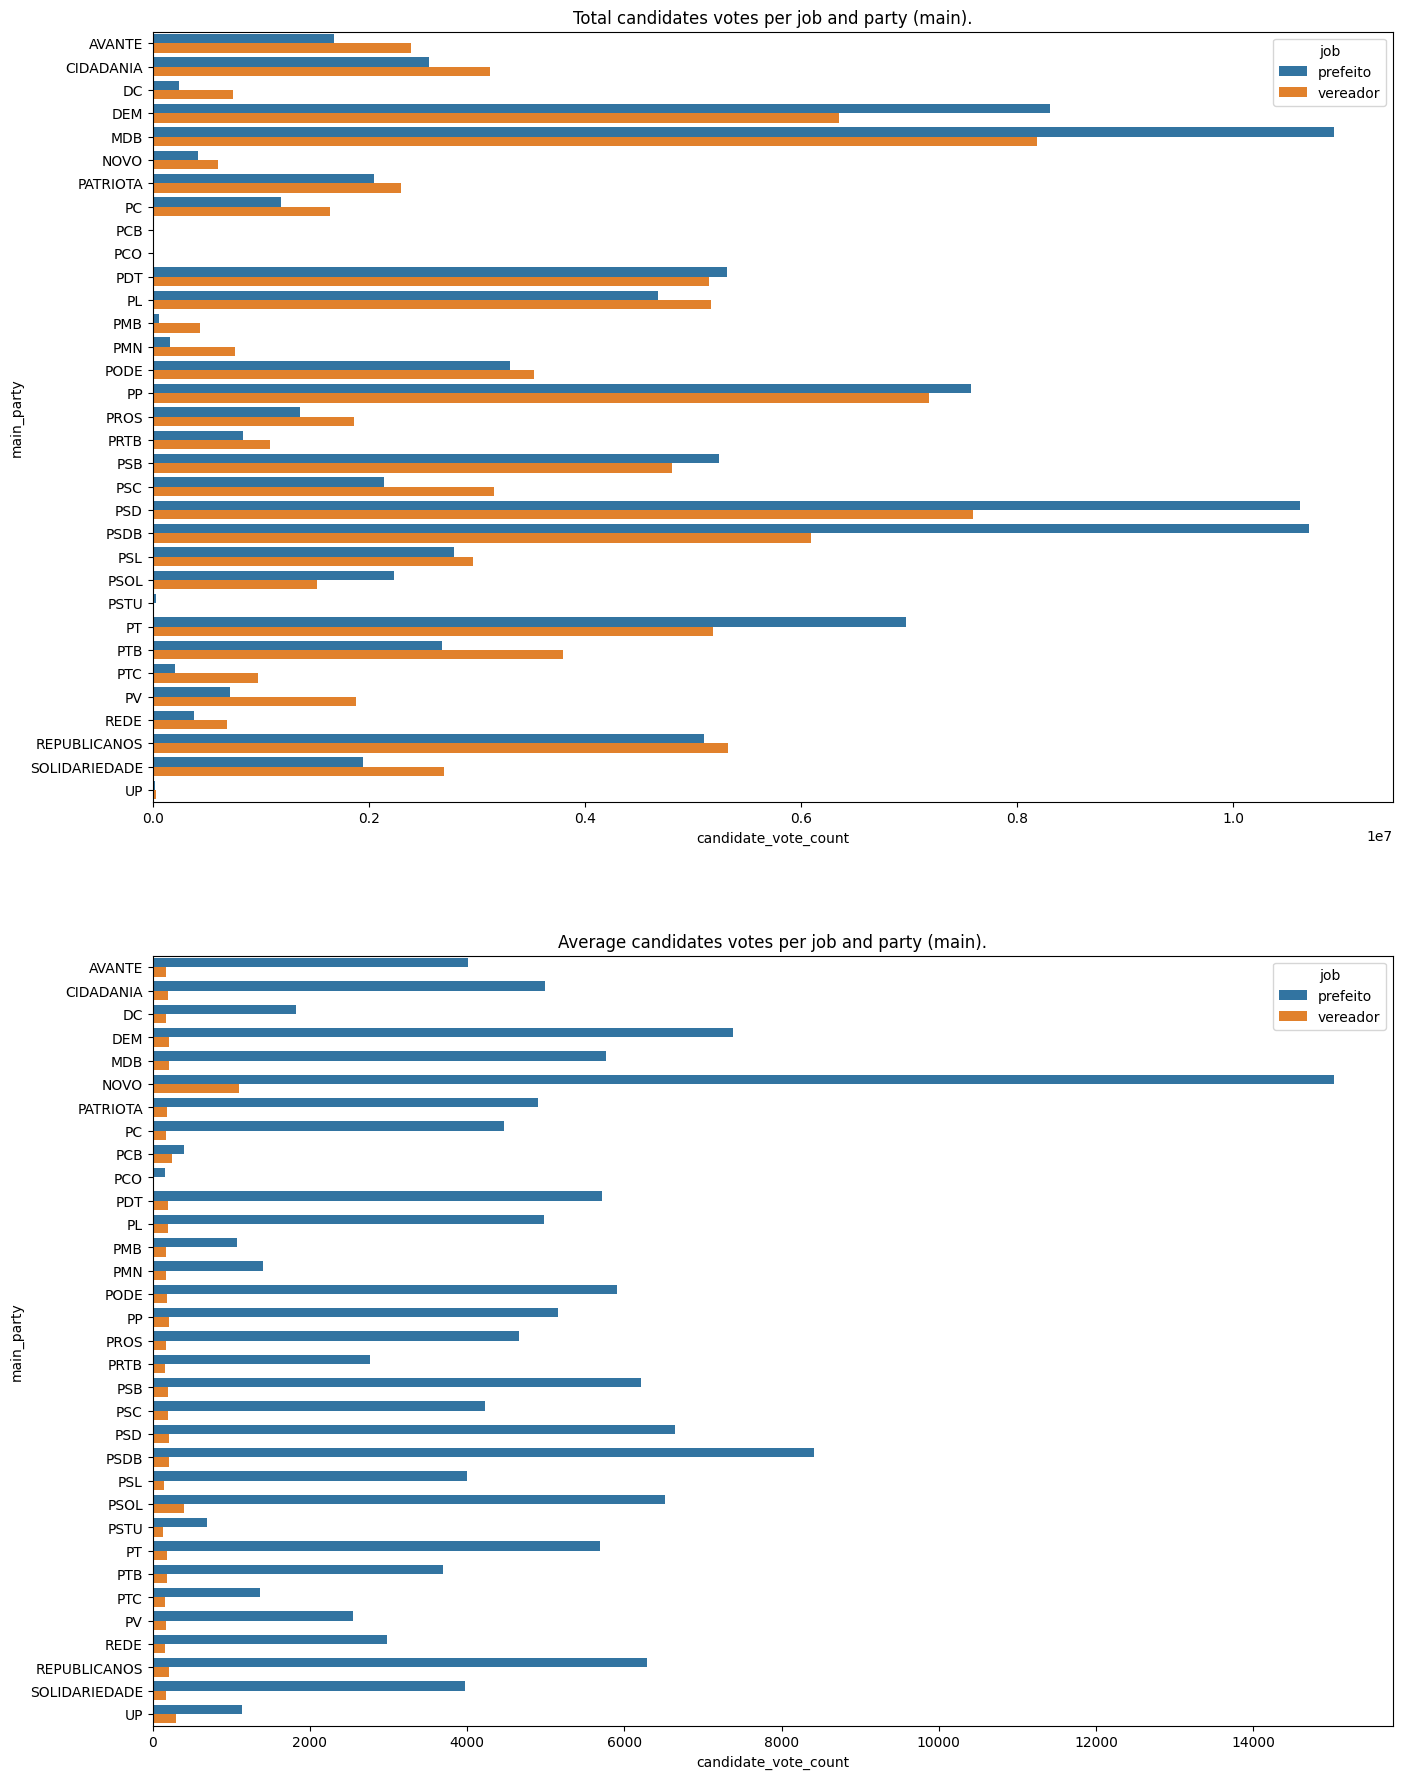

In [26]:
fig, eixo = plt.subplots(2, 1, figsize=(16, 22))

eixo = eixo.flatten()

vote_per_party = data_frame.groupby(by=['job', 'main_party'])['candidate_vote_count'].sum()
vote_per_party = vote_per_party.reset_index()

g = sns.barplot(
    data=vote_per_party,
    x='candidate_vote_count',
    y='main_party',
    hue='job',
    ax=eixo[0]
)

g.set_title('Total candidates votes per job and party (main).')

vote_per_party = data_frame.groupby(by=['job', 'main_party'])['candidate_vote_count'].mean()
vote_per_party = vote_per_party.reset_index()

h = sns.barplot(
    data=vote_per_party,
    x='candidate_vote_count',
    y='main_party',
    hue='job',
    ax=eixo[1]
)

h.set_title('Average candidates votes per job and party (main).')

plt.savefig(FIGURES_DIR / 'candidate_votes_job_party.png')

For some main parties considered small in Brazil (AVANTE, CIDADANIA, DC
and other), the total votes for councilors are greater than mayors. Since
the campaign for councilors are usually cheaper than mayors, then this
could explain why we found this result. However, in average number of
votes, mayors received many more votes than councilors. These graphs show
that the job of mayor tend to receive less votes than councilors when the
main party is small, in contrast, when the party is big, the situation
tends to be the opposite.

The latest graphs allowed us to understand more about the relation between
party, state and vote. Now we are going to check some data about elected
mayors and councilors.

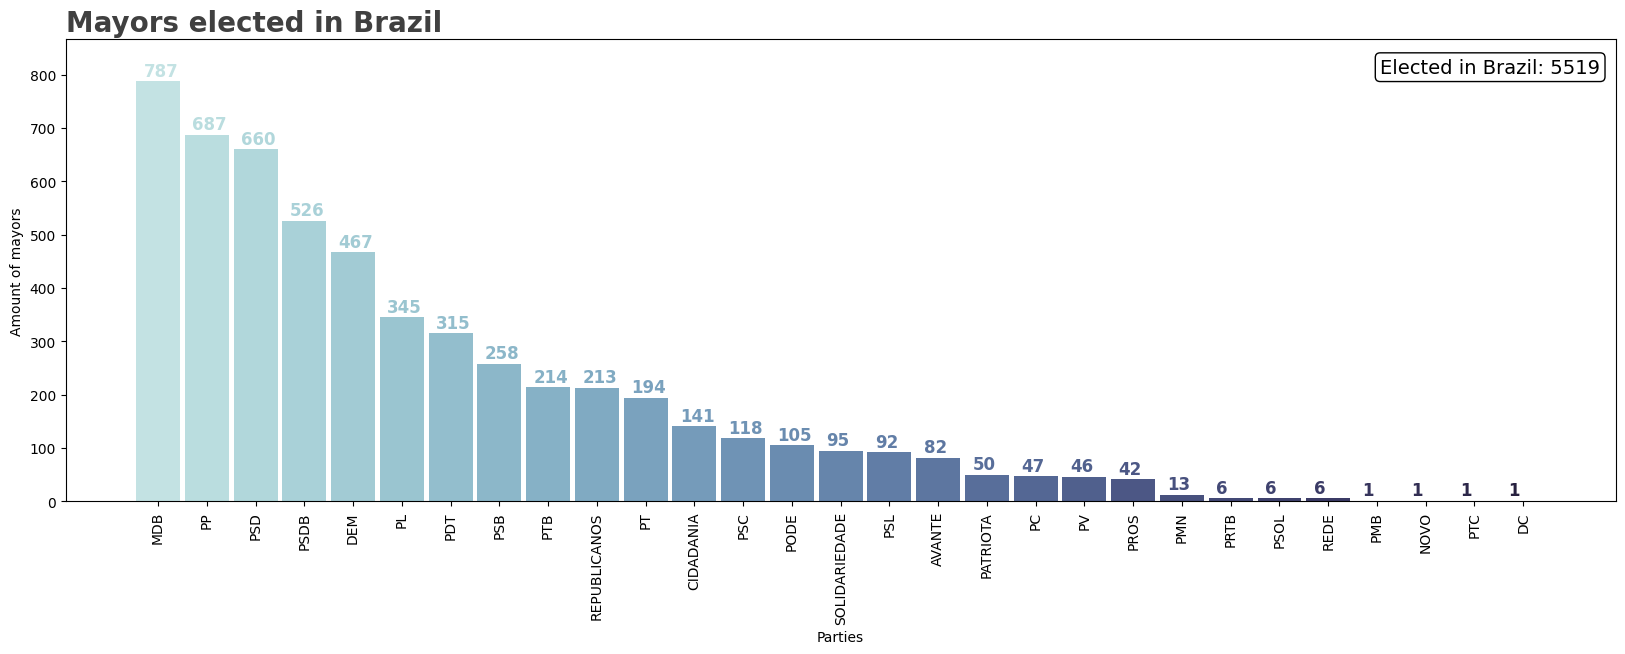

In [27]:
## Analyzing the number of mayors elected by main party
query_mayors = data_frame[
    (data_frame['job'] == 'prefeito') &
    (data_frame['elector_count'] == 's')
]

mayors_analysis = query_mayors.groupby(by=['main_party']).agg(
    amount=('candidate_vote_count', 'count')
)

number_elected_mayors = mayors_analysis['amount'].sum()
mayors_analysis['%'] = mayors_analysis['amount'] / number_elected_mayors * 100
mayors_analysis['%'] = round(mayors_analysis['%'], 2)
mayors_analysis.sort_values('amount', inplace=True, ascending=False)

## plotting the graphic with the analyzes mayors_analysis
## creating a pallet of colors using seaborn
color_palette = sns.color_palette("ch:s=.2,rot=-.3", 
                                  len(mayors_analysis))

## configuring the size of the graph
plt.figure(figsize=(20,6))

## plotting the graph itself
plt.bar(mayors_analysis.index,
        mayors_analysis['amount'],
        width=0.9,
        color=color_palette)

## configuring the title
plt.title('Mayors elected in Brazil',
          loc='left',
          fontsize=20,
          color='#404040',
          fontweight=600)

## configuring the labels
plt.ylabel('Amount of mayors')
plt.xlabel('Parties')
plt.xticks(rotation=90)

## changing y axis limit value to add some space after the
## maximum value
plt.ylim(0, mayors_analysis['amount'].max() * 1.1)

## adding labels for each bar of the graph
for position, value in enumerate(mayors_analysis['amount']):
    plt.text(
        ## position of the label
        position -0.3,
        value +10,
        ## label text
        value,
        ## label color
        color=color_palette[position],
        ## label size and font
        size=12,
        fontweight=700
    )

plt.annotate(
    f'Elected in Brazil: {mayors_analysis["amount"].sum()}',
    xy=(0.99,0.94),
    xycoords='axes fraction',
    ha='right',
    va='center',
    color='black',
    fontsize=14,
    bbox=dict(facecolor='#ffffff',
               edgecolor='black',
               boxstyle='round',
               pad=0.25)
)

plt.savefig(FIGURES_DIR / 'mayor_analysis.png')

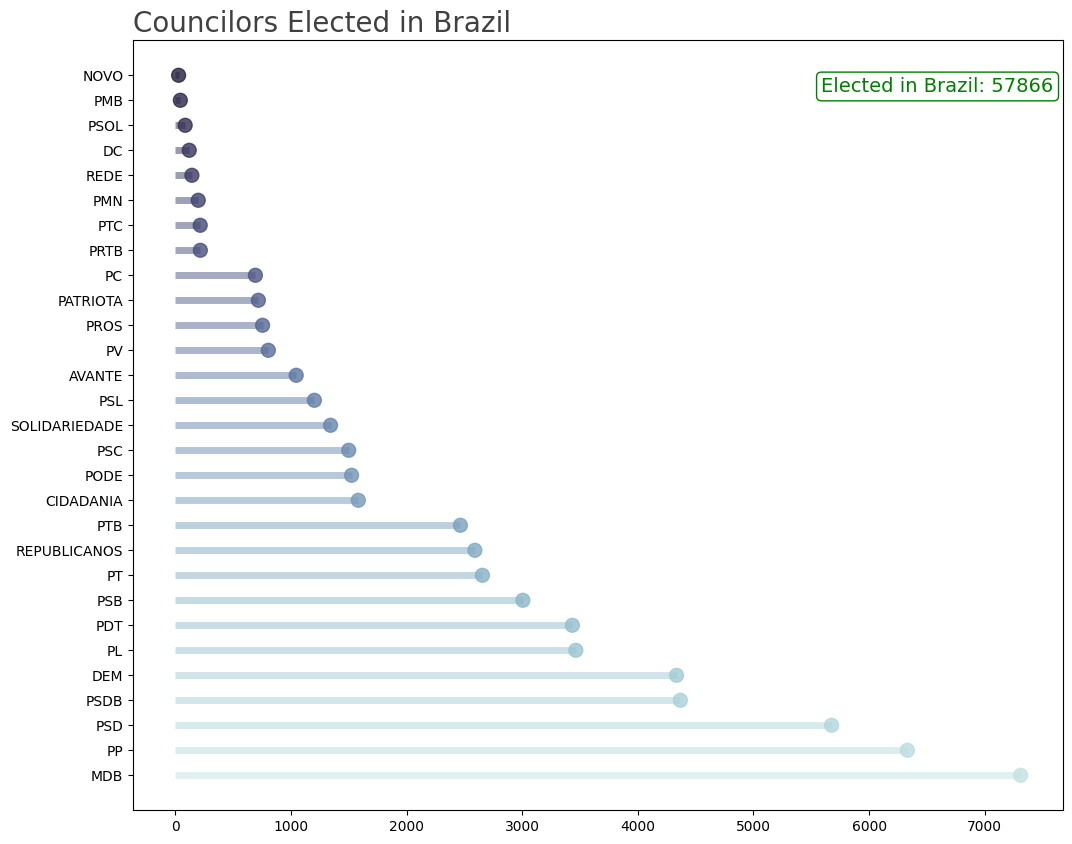

In [28]:
## analyzing data for councilors
query_councilors = data_frame[
    (data_frame['job'] == 'vereador') &
    (data_frame['elector_count'] == 's')
]

councilors_analysis = query_councilors.groupby(by='main_party').agg(
    amount = ('candidate_vote_count', 'count')
)

number_elected_councilors = councilors_analysis['amount'].sum()
councilors_analysis['%'] = councilors_analysis['amount'] / number_elected_councilors * 100
councilors_analysis['%'] = round(councilors_analysis['%'], 2)
councilors_analysis.sort_values('amount', inplace=True, ascending=False)

plt.figure(figsize=(12,10))
plt.hlines(
    y=councilors_analysis.index,
    xmin=0,
    xmax=councilors_analysis['amount'],
    lw=5,
    color=color_palette,
    alpha=0.5
)

plt.scatter(
    councilors_analysis['amount'],
    councilors_analysis.index,
    s=100,
    color=color_palette,
    alpha=0.8
)

plt.title('Councilors Elected in Brazil',
          loc='left',
          fontsize=20,
          color='#404040',
          fontweight=500)

plt.annotate(
    f'Elected in Brazil: {councilors_analysis["amount"].sum()}',
    xy=(0.99,0.94),
    xycoords='axes fraction',
    ha='right',
    va='center',
    color='green',
    fontsize=14,
    bbox=dict(facecolor='#ffffff',
               edgecolor='green',
               boxstyle='round',
               pad=0.25)
)

plt.savefig(FIGURES_DIR / 'councilors_analysis.png')

From the last two graphs, we can note the representative of the main parties
for councilors and mayors. Moreover, we can tell which party can be
considered big in Brazil by the number of elected mayors or
councilors. For example, we can consider the first five parties (for both
jobs) big.

For the last, we will check if there is any relationship between the
number of mayors and councilors elected by party.

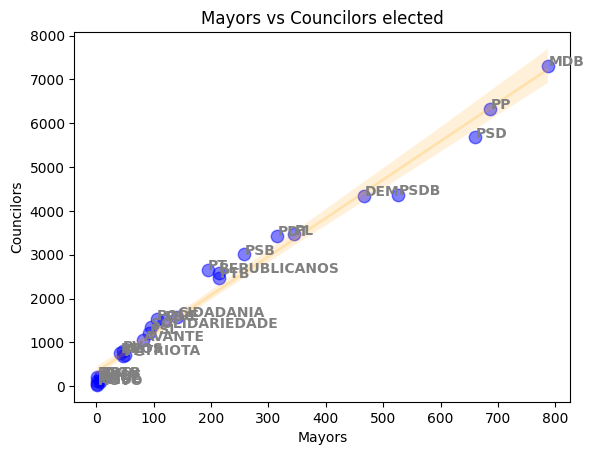

In [29]:
## correlation analysis
## checking if there is any relationship between the number of mayors
## and councilors elected by party
correlation_table = mayors_analysis['amount'].reset_index()
correlation_table = pd.merge(correlation_table,
                             councilors_analysis.reset_index(),
                             on=['main_party'],
                             how='inner')
correlation_table.columns = ['Party', 'Mayors', 'Councilors', '%']
correlation_table.drop(columns=['%'], inplace=True)

sns.regplot(
    x=correlation_table['Mayors'],
    y=correlation_table['Councilors'],
    ci=95,
    scatter_kws={
        'color': 'blue',
        's': 80,
        'alpha': 0.5},
    line_kws={
        'color': 'orange',
        'alpha': 0.2,
        'lw': 2
    }
)

plt.title('Mayors vs Councilors elected')

## adding the party for mayors and councilors
for line in range(0, correlation_table.shape[0]):
    plt.text(
        correlation_table['Mayors'][line] + 0.8,
        correlation_table['Councilors'][line],
        correlation_table['Party'][line],
        size='medium',
        color='gray',
        weight='semibold'
    )

plt.savefig(FIGURES_DIR / 'correlation_analysis.png')

We can see that there is postive correlantion between the number of elected
councilors and mayors, indicating that bigger parties tend to elect more
cancidates.

# Conclusion

For the election dataset from 2022, we could describe its categorical and
numerical data. About candidate vote data, we found they are highly
concentrated at first bins of histograms and are asymmetric to right. We
further analyzed them and found the candidate vote is highly influenced by
its job. The state important when we consider the total candidate votes,
but in average its importance is reduced. For both jobs, we found a few
candidates receive a high amount of votes, whereas most of candidates do
not. These results explain why the data on histograms are concentrated at
the firsts bins. We and found a positive correlation between the number of
councilors and mayors elected by party. Our exploratory data analysis
could provide some insight about the data and it could be extended by
analyzing more previous data.